# 02 — Limpieza y Preprocesamiento de Comentarios

## Objetivo
Transformar los comentarios crudos de YouTube en un dataset limpio, filtrado por idioma y listo para los modelos de NLP (análisis de sentimiento, topic modeling y NER).

## Flujo del pipeline
1. Cargar datos crudos desde `data/raw/youtube_comments.parquet`.
2. Eliminar comentarios marcados como spam (`is_spam == True`).
3. Eliminar comentarios vacíos, `[deleted]` o que solo contienen whitespace.
4. Deduplicar por `text_hash` (SHA-256 del texto limpio).
5. Limpiar el texto (URLs, menciones, timestamps, HTML entities).
6. Detectar idioma con `langdetect` y filtrar solo español (`es`) e inglés (`en`).
7. Tokenizar con spaCy (lematización + eliminación de stopwords/puntuación).
8. Guardar datos procesados en `data/processed/comentarios_limpios`.

## Valor para el negocio
Garbage in → garbage out. Una limpieza rigurosa impacta directamente la precisión de los modelos posteriores. La decisión de **conservar emojis** en el texto (en lugar de eliminarlos) busca preservar la señal emocional que aportan en reacciones futbolísticas ("\U0001f1e7\U0001f1f7\U0001f525").

---

### 1. Cargar datos crudos

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import spacy

# Ensure project root is on sys.path for src imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing import (
    clean_text,
    deduplicate_comments,
    detect_language,
    extract_emojis,
    is_likely_spam,
    preprocess_comment,
    tokenize_text,
)
from src.data_collection import load_collected
from src.config import PROCESSED_DIR, SUPPORTED_LANGUAGES, SPACY_MODELS
from src.utils import save_dataframe

print(f"Project root: {project_root}")

Project root: /home/runner/work/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-


/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
df_raw = load_collected(format='parquet')

if df_raw.empty:
    print("=" * 60)
    print("  NO HAY DATOS CRUDOS DISPONIBLES")
    print("  Ejecuta primero el pipeline de recolección:")
    print("    python -m src.pipeline --step collect")
    print("=" * 60)
else:
    print(f"Comentarios crudos cargados: {len(df_raw)}")
    print(f"Columnas: {list(df_raw.columns)}")
    display(df_raw.head(3))

Comentarios crudos cargados: 71829
Columnas: ['comment_id', 'video_id', 'parent_id', 'text', 'author', 'published_at', 'like_count', 'total_reply_count', 'source', 'collected_at', 'text_hash', 'teams', 'video_title', 'video_published_at', 'search_team', 'search_opponent', 'match_date', 'is_spam']


,comment_id,video_id,parent_id,text,author,published_at,like_count,total_reply_count,source,collected_at,text_hash,teams,video_title,video_published_at,search_team,search_opponent,match_date,is_spam
0,UgwwDPLJjlDGz5havpp4AaABAg,DX5wBEslnQI,,People forget this was the same way Morocco pl...,@ballack4bernard,2026-06-14T00:53:27Z,363,7,youtube,2026-06-14T19:05:28.093398+00:00,c612d5fc40fbabc3813d724ef2d6f2f5e277e77f6ba9f0...,Brazil,Brazil vs Morocco Highlights 🌎🏆 2026 FIFA Worl...,2026-06-14T00:19:40Z,Brazil,Morocco,2026-06-13 22:00:00+00:00,False
1,UgwwDPLJjlDGz5havpp4AaABAg.AY0VvTd861YAY0q4ljzRP_,DX5wBEslnQI,UgwwDPLJjlDGz5havpp4AaABAg,People also forget that Brazil has been chokin...,@RockSmithStudio,2026-06-14T03:58:21Z,30,0,youtube,2026-06-14T19:05:28.705011+00:00,635a0326e2875ab33b100234fb5c0232c691cf27baa570...,Brazil,Brazil vs Morocco Highlights 🌎🏆 2026 FIFA Worl...,2026-06-14T00:19:40Z,Brazil,Morocco,2026-06-13 22:00:00+00:00,False
2,UgwwDPLJjlDGz5havpp4AaABAg.AY0VvTd861YAY0vEL2GF5s,DX5wBEslnQI,UgwwDPLJjlDGz5havpp4AaABAg,@RockSmithStudiostill better than Italy,@Platohato,2026-06-14T04:43:21Z,4,0,youtube,2026-06-14T19:05:28.705040+00:00,762d4803e2fd2d949358dbd8dae359000cf7f1c0c2e092...,Brazil,Brazil vs Morocco Highlights 🌎🏆 2026 FIFA Worl...,2026-06-14T00:19:40Z,Brazil,Morocco,2026-06-13 22:00:00+00:00,False


---

### 2. Funnel de limpieza

A continuación aplicamos cada paso de filtrado secuencialmente y registramos cuántos comentarios se eliminan en cada etapa.

In [3]:
if not df_raw.empty:
    funnel = []
    n0 = len(df_raw)
    funnel.append(("Comentarios crudos", n0))
    print(f"Punto de partida: {n0} comentarios")
else:
    print("Dataset vacío — no se puede continuar con el funnel.")
    funnel = []

Punto de partida: 71829 comentarios


#### 2a. Eliminar spam

Los comentarios marcados como `is_spam == True` durante la recolección se eliminan aquí. La marca `is_spam` se añadió en la fase de recolección (Parte 2b del proyecto), lo que permite mantener el archivo crudo completo y realizar el filtrado aguas abajo.

In [4]:
if not df_raw.empty:
    df = df_raw.copy()
    n_spam = df['is_spam'].sum()
    df = df[~df['is_spam']].copy()
    funnel.append(("Sin spam", len(df)))
    print(f"Eliminados por spam: {n_spam} ({n_spam / n0 * 100:.1f}% del total)")
    print(f"Restantes: {len(df)}")

Eliminados por spam: 62 (0.1% del total)
Restantes: 71767


#### 2b. Eliminar comentarios vacíos / eliminados / whitespace

In [5]:
if not df_raw.empty:
    def _is_deleted_or_empty(t):
        if not isinstance(t, str):
            return True
        stripped = t.strip()
        if not stripped or stripped in ('[deleted]', '[removed]', ''):
            return True
        return False

    n_before = len(df)
    df = df[~df['text'].apply(_is_deleted_or_empty)].copy()
    n_empty = n_before - len(df)
    funnel.append(("Sin vacíos/deleted", len(df)))
    print(f"Eliminados vacíos/deleted: {n_empty}")
    print(f"Restantes: {len(df)}")

Eliminados vacíos/deleted: 0
Restantes: 71767


#### 2c. Deduplicar por `text_hash`

In [6]:
if not df_raw.empty:
    n_before = len(df)
    df = deduplicate_comments(df)
    funnel.append(("Sin duplicados", len(df)))
    print(f"Restantes: {len(df)}")

Restantes: 71767


---

### 3. Limpieza de texto

Aplicamos `clean_text()` a cada comentario y guardamos el resultado en una nueva columna `text_clean`. La función:
- Decodifica entidades HTML (`&amp;` → `&`).
- Elimina URLs y menciones `@usuario`.
- Elimina timestamps de YouTube (`1:23`, `12:34`).
- Elimina marcadores de lista (`-`, `•`, `*`) al inicio/final.
- Colapsa caracteres repetidos (`nooooo` → `nooo`).
- **Conserva los emojis** (decisión documentada más abajo).

In [7]:
if not df_raw.empty:
    df['text_clean'] = df['text'].apply(clean_text)
    df['emojis_raw'] = df['text'].apply(extract_emojis)
    df['emojis'] = df['emojis_raw'].apply(lambda x: ''.join(x) if x else '')
    df['n_emojis'] = df['emojis_raw'].apply(len)
    df.drop(columns=['emojis_raw'], inplace=True)

    print("Muestra antes/después de limpiar:")
    comparison = df[['text', 'text_clean', 'emojis', 'n_emojis']].head(5)
    display(comparison)

Muestra antes/después de limpiar:


,text,text_clean,emojis,n_emojis
0,People forget this was the same way Morocco pl...,People forget this was the same way Morocco pl...,,0
1,People also forget that Brazil has been chokin...,People also forget that Brazil has been chokin...,,0
2,@RockSmithStudiostill better than Italy,better than Italy,,0
3,@Platohato 😂 true,😂 true,😂,1
4,Return of the moors lol,Return of the moors lol,,0


---

### 4. Detección de idioma

Usamos `langdetect` para identificar el idioma de cada comentario. Solo conservamos español (`es`) e inglés (`en`), que son los idiomas soportados por nuestros modelos BERT.

Distribución de idiomas (antes de filtrar):
  en:  41611 ( 58.0%)
  es:  13548 ( 18.9%)
  unknown:   4952 (  6.9%)
  pt:   1477 (  2.1%)
  it:    974 (  1.4%)
  fr:    691 (  1.0%)
  de:    626 (  0.9%)
  id:    623 (  0.9%)
  cy:    567 (  0.8%)
  so:    567 (  0.8%)
  ca:    503 (  0.7%)
  nl:    429 (  0.6%)
  tl:    401 (  0.6%)
  af:    400 (  0.6%)
  ja:    383 (  0.5%)
  ar:    267 (  0.4%)
  et:    260 (  0.4%)
  ru:    255 (  0.4%)
  bn:    234 (  0.3%)
  sw:    229 (  0.3%)
  sl:    227 (  0.3%)
  ro:    225 (  0.3%)
  tr:    225 (  0.3%)
  fi:    225 (  0.3%)
  no:    215 (  0.3%)
  hr:    189 (  0.3%)
  vi:    187 (  0.3%)
  da:    182 (  0.3%)
  ko:    157 (  0.2%)
  pl:    151 (  0.2%)
  hu:    125 (  0.2%)
  lt:    123 (  0.2%)
  sv:    116 (  0.2%)
  sq:     71 (  0.1%)
  sk:     62 (  0.1%)
  cs:     49 (  0.1%)
  fa:     43 (  0.1%)
  zh-cn:     38 (  0.1%)
  lv:     36 (  0.1%)
  bg:     29 (  0.0%)
  th:     18 (  0.0%)
  ml:     17 (  0.0%)
  mk:     16 (  0.0%)
  

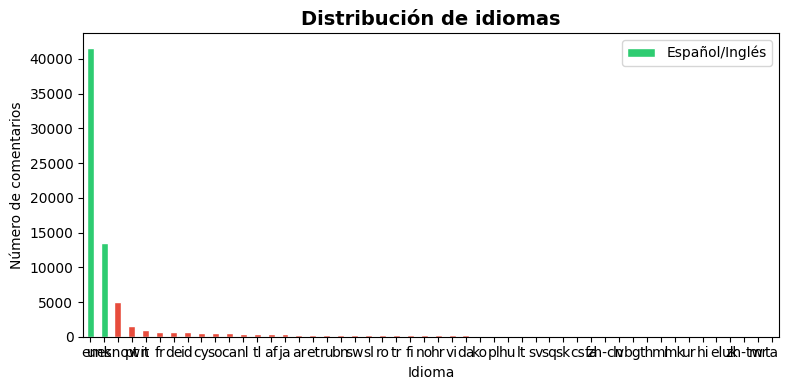

In [8]:
if not df_raw.empty:
    lang_results = df['text_clean'].apply(detect_language)
    df['language'] = lang_results.apply(lambda x: x[0])
    df['lang_confidence'] = lang_results.apply(lambda x: x[1])

    # Distribution before filtering
    dist = df['language'].value_counts()
    total = len(df)
    print("Distribución de idiomas (antes de filtrar):")
    for lang, count in dist.items():
        print(f"  {lang}: {count:>6} ({count/total*100:5.1f}%)")

    # Bar chart
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ['#2ecc71' if l in SUPPORTED_LANGUAGES else '#e74c3c' for l in dist.index]
    dist.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title('Distribución de idiomas', fontsize=14, fontweight='bold')
    ax.set_xlabel('Idioma')
    ax.set_ylabel('Número de comentarios')
    ax.legend(['Español/Inglés' if c == '#2ecc71' else 'Otros' for c in colors])
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [9]:
if not df_raw.empty:
    n_before_lang = len(df)
    df = df[df['language'].isin(SUPPORTED_LANGUAGES)].copy()
    n_dropped_lang = n_before_lang - len(df)
    funnel.append(("Solo es/en", len(df)))
    print(f"Eliminados por idioma no soportado: {n_dropped_lang} ({n_dropped_lang/n_before_lang*100:.1f}%)")
    print(f"Restantes: {len(df)}")

Eliminados por idioma no soportado: 16608 (23.1%)
Restantes: 55159


---

### 5. Tokenización con spaCy

Cargamos los modelos de spaCy para español (`es_core_news_sm`) e inglés (`en_core_web_sm`). Aplicamos tokenización con lematización y eliminación de stopwords/puntuación.

In [10]:
if not df_raw.empty:
    try:
        nlp_es = spacy.load('es_core_news_sm')
        nlp_en = spacy.load('en_core_web_sm')
        print("Modelos spaCy cargados correctamente")
        print(f"  es_core_news_sm: {nlp_es.meta['version']}")
        print(f"  en_core_web_sm: {nlp_en.meta['version']}")
        spacy_available = True
    except OSError as e:
        print(f"Error cargando modelos spaCy: {e}")
        print("Instala los modelos con:")
        print("  python -m spacy download es_core_news_sm")
        print("  python -m spacy download en_core_web_sm")
        spacy_available = False

Modelos spaCy cargados correctamente
  es_core_news_sm: 3.8.0
  en_core_web_sm: 3.8.0


In [11]:
if not df_raw.empty and spacy_available:
    df['tokens'] = df.apply(
        lambda r: tokenize_text(r['text_clean'], r['language'], nlp_es, nlp_en),
        axis=1,
    )

    print("Ejemplos de tokenización:")
    for i, (_, r) in enumerate(df.head(3).iterrows()):
        print(f"\n--- Ejemplo {i+1} ({r['language']}) ---")
        print(f"  Original:  {r['text'][:100]}...")
        print(f"  Limpio:    {r['text_clean'][:100]}...")
        print(f"  Tokens:    {r['tokens'][:15]}...")
        print(f"  # tokens:  {len(r['tokens'])}")

Ejemplos de tokenización:

--- Ejemplo 1 (en) ---
  Original:  People forget this was the same way Morocco played last WC and knocked out Spain and Portugal...
  Limpio:    People forget this was the same way Morocco played last WC and knocked out Spain and Portugal...
  Tokens:    ['people', 'forget', 'way', 'morocco', 'play', 'wc', 'knock', 'spain', 'portugal']...
  # tokens:  9

--- Ejemplo 2 (en) ---
  Original:  People also forget that Brazil has been choking the World Cup for decades now...
  Limpio:    People also forget that Brazil has been choking the World Cup for decades now...
  Tokens:    ['people', 'forget', 'brazil', 'choke', 'world', 'cup', 'decade']...
  # tokens:  7

--- Ejemplo 3 (en) ---
  Original:  @RockSmithStudiostill better than Italy...
  Limpio:    better than Italy...
  Tokens:    ['well', 'italy']...
  # tokens:  2


---

### 6. Resumen del funnel de limpieza

A continuación se muestra una tabla resumen con cada etapa del pipeline y cuántos comentarios se conservan.

In [12]:
if funnel:
    funnel_df = pd.DataFrame(funnel, columns=['Etapa', 'Comentarios'])
    funnel_df['Eliminados'] = funnel_df['Comentarios'].diff().abs().fillna(0).astype(int)
    funnel_df['% Acumulado'] = (funnel_df['Comentarios'] / funnel_df['Comentarios'].iloc[0] * 100).round(1)
    display(funnel_df)
    print(f"\nTotal comentarios procesados: {funnel_df['Comentarios'].iloc[-1]}")
    print(f"Retención: {funnel_df['% Acumulado'].iloc[-1]}% del total crudo")

,Etapa,Comentarios,Eliminados,% Acumulado
0,Comentarios crudos,71829,0,100.0
1,Sin spam,71767,62,99.9
2,Sin vacíos/deleted,71767,0,99.9
3,Sin duplicados,71767,0,99.9
4,Solo es/en,55159,16608,76.8



Total comentarios procesados: 55159
Retención: 76.8% del total crudo


---

### 7. Decisiones de limpieza y justificación

A continuación se documentan las decisiones clave de limpieza y su fundamento:

- **Conservación de emojis**: A diferencia de pipelines tradicionales de NLP que eliminan emojis, hemos decidido conservarlos en `text_clean`. Los emojis aportan una señal emocional muy relevante en comentarios deportivos ("\U0001f1e7\U0001f1f7\U0001f525", "\U0001f389") que complementa el análisis de sentimiento basado en texto. Además, se extraen en una columna separada `emojis` para su uso como feature independiente.

- **Filtrado por idioma (es/en)**: Los modelos BERT que utilizamos (pysentimiento para español, RoBERTa para inglés) son específicos por idioma. Mantener solo `es` y `en` evita predicciones erróneas en idiomas no soportados. Los comentarios detectados como `unknown` suelen ser muy cortos o basados solo en emojis, y su exclusión es una pérdida mínima.

- **Deduplicación por `text_hash`**: El hash SHA-256 se calcula sobre el texto ya limpio para capturar duplicados exactos, incluyendo aquellos donde el mismo usuario comenta lo mismo en múltiples videos. La deduplicación evita que ciertos comentarios inflen las métricas de sentimiento.

- **Spam marcado en recolección, filtrado aquí**: La columna `is_spam` se añade durante la recolección (Parte 2b) para mantener el archivo crudo completo. El filtrado se aplica en este notebook, permitiendo re-analizar en el futuro si el detector de spam mejora.

- **Comentarios muy cortos (baja señal)**: El umbral `min_length=10` caracteres en `preprocess_comment` elimina comentarios demasiado cortos para análisis. Adicionalmente, `is_low_signal()` en `src/preprocessing.py` permite detectar comentarios sin referencia a equipos ni fútbol, aunque esta función no se aplica automáticamente en el pipeline base.

- **Timestamps de YouTube**: Se eliminan porque hacen referencia a momentos del video ("mira el 1:23") y no aportan contenido léxico útil para el análisis de sentimiento o topic modeling.

---

### 8. Guardar datos procesados

In [13]:
if not df_raw.empty:
    output_dir = PROCESSED_DIR / "comentarios_limpios"
    output_dir.mkdir(parents=True, exist_ok=True)

    save_dataframe(df, str(output_dir / "comentarios_limpios"), format='parquet')
    save_dataframe(df, str(output_dir / "comentarios_limpios"), format='csv')

    print(f"Datos guardados en: {output_dir}")
    print(f"  comentarios_limpios.parquet")
    print(f"  comentarios_limpios.csv")
    print(f"\nDimensiones finales: {df.shape[0]} filas x {df.shape[1]} columnas")
    print(f"Columnas: {list(df.columns)}")
else:
    print("No hay datos que guardar — ejecuta primero la recolección.")

Datos guardados en: /home/runner/work/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-/An-lisis-de-sentimiento-de-los-aficionadosMundial-2026-/data/processed/comentarios_limpios
  comentarios_limpios.parquet
  comentarios_limpios.csv

Dimensiones finales: 55159 filas x 24 columnas
Columnas: ['comment_id', 'video_id', 'parent_id', 'text', 'author', 'published_at', 'like_count', 'total_reply_count', 'source', 'collected_at', 'text_hash', 'teams', 'video_title', 'video_published_at', 'search_team', 'search_opponent', 'match_date', 'is_spam', 'text_clean', 'emojis', 'n_emojis', 'language', 'lang_confidence', 'tokens']


---

**Siguiente paso**: [03 — Análisis de Sentimiento](03_analisis_sentimiento.ipynb)